### Notas de aula de Mecânica Quântica <br> Autor: Jonas Maziero

# Íon da molécula de hidrogênio $(H_{2}^{+})$

Neste caso temos um sistema quântico constituído por 2 prótons, em 2 núcleos separados, e 1 elétron. Consideremos que os 2 prótons estão fixos a uma distância $R$ um do outro (veja a figura abaixo). Um os dos principais produtos do nosso cálculo será obter uma estimativa para o valor de $R$. Com a suposição de $R$ fixo, teremos que o hamiltoniano desse sistema será
$$H = -\frac{\hbar^{2}}{2m_{e}}\nabla^{2} -ke^{2}\Big(\frac{1}{r_{1}}+\frac{1}{r_{2}}\Big).$$
A _energia de repulsão entre os prótons_, 
$$U_{pp} = \frac{ke^2}{R},$$
pode ser incluída depois que obtermos $R$, que por enquanto será considerado fixo. 

<img src='fig_H2+.png' width='250'>

Se ignoramos um dos prótons, a função de onda é aquela do átomo de hidrogênio. Para o estado fundamental temos a função de onda normalizada (veja o código abaixo):
$$\psi_{0}(r) = \frac{1}{\sqrt{\pi a_{0}^{3}}}e^{-r/a_{0}}.$$

Assim, como uma 1ª tentativa de função de onda variacional, podemos usar
$$\phi = A\big(\psi_{0}(r_{1})+\psi_{0}(r_{2})\big).$$
Podemos interpretar esse estado como descrevendo o elétron como uma superposição de funções de onda individuais que descrevem sua interação com um único núcleo.

Esse tipo de função de onda molecular é usualmente chamado de CLOA, que é a sigla para Combinação Linear de Orbitais Atômicos (__LCAO__, que é a sigla para __Linear Combination of Atomic Orbitals__). Pela simetria do sistema por troca dos prótons, temos que os módulos dos coeficientes na combinação linear devem ser iguais. Usaremos o sinal de mais, que leva a um estado ligado. Ficará como exercício mostrar que o uso do sinal de menos leva a um estado não ligado.

In [7]:
from sympy import pi, oo, symbols, integrate, exp, init_printing
init_printing(use_unicode=True)
r, a0 = symbols('r a_{0}', positive=True)
integrate(r**2*(1/(pi*a0**3))*exp(-2*r/a0),(r,0,oo))*4*pi # ok psi0 esta normalizada

Normalizando
\begin{align}
& \int d^{3}r |\phi|^{2} = 1 \\
& = |A|^{2}\int d^{3}r\big(|\psi_{0}(r_{1})|^{2}+|\psi_{0}(r_{2})|^{2}+2\psi_{0}(r_{1})\psi_{0}(r_{2})\big) \\
& = |A|^{2}\Big(1+1+\frac{2}{\pi a_{0}^{3}}\int d^{3}r e^{-(r_{1}+r_{2})/a_{0}}\big) \\
& =: |A|^{2}2(1+I), \\
& \therefore A = \frac{1}{\sqrt{2(1+I)}}.
\end{align}

<img src='fig_H2+_ref1.png' width='300'>

Seguindo, escolhemos o __referencial__ de forma que o próton 1 está na orgigem e o próton 2 está no eixo positivo $z$. Teremos assim que
$$r_{1}=r \text{ e } r_{2} =r'= \sqrt{r^{2}+R^{2}-2rR\cos\theta},$$
em que $\theta$ é o ângulo entre $\vec{r}$ e o eixo $z$ ($\hat{k}$). Com isso, teremos que a chamada __integral de sobreposição__ (de _overlap_) é
\begin{align}
I & = \langle\psi_{0}(r_{1})|\psi_{0}(r_{2})\rangle \\
& = \int d^{3}r \psi_{0}(r_{1})^{*}\psi_{0}(r_{2})\\
& = \frac{1}{\pi a_{0}^{3}}\int d^{3}r e^{-(r_{1}+r_{2})/a_{0}} \\
& = \frac{1}{\pi a_{0}^{3}}\int_{0}^{\infty}r^{2}dr\int_{0}^{\pi}\sin\theta d\theta e^{-\big(r+\sqrt{r^{2}+R^{2}-2rR\cos\theta}\big)/a_{0}}\int_{0}^{2\pi}d\phi \\
& = 2\pi\frac{1}{\pi a_{0}^{3}}\int_{0}^{\infty}r^{2}e^{-r/a_{0}}dr\int_{0}^{\pi}\sin\theta d\theta e^{-\sqrt{r^{2}+R^{2}-2rR\cos\theta}/a_{0}}.
\end{align}

Seguindo, fazemos a seguinte mudança de variável
\begin{align}
& y = \sqrt{r^{2}+R^{2}-2rR\cos\theta}/a_{0} \ \therefore\ a_{0}^{2}y^{2} = r^{2}+R^{2}-2rR\cos\theta \\
& \therefore\ a_{0}^{2}d(y^{2}) = a_{0}^{2}2ydy = 2rR\sin\theta d\theta \ \therefore\ \sin\theta d\theta =  \frac{a_{0}^{2}ydy}{rR}; \\
& \begin{cases} \theta = 0 \ \therefore\ y = \sqrt{(r-R)^{2}}/a_{0} = |r-R|/a_{0}, \\ \theta = \pi \ \therefore\ y = \sqrt{(r+R)^{2}}/a_{0} = (r+R)/a_{0} \end{cases}.
\end{align}

Assim
\begin{align}
I & = \frac{1}{\pi a_{0}^{3}}2\pi\int_{0}^{\infty}r^{2}e^{-r/a_{0}}dr\int_{|r-R|/a_{0}}^{(r+R)/a_{0}}\frac{a_{0}^{2}ydy}{rR}e^{-y} \\
& = \frac{1}{\pi a_{0}^{3}}\frac{2\pi a_{0}^{2}}{R}\int_{0}^{\infty}re^{-r/a_{0}}dr\int_{|r-R|/a_{0}}^{(r+R)/a_{0}}ye^{-y}dy \\
& = \frac{1}{\pi a_{0}^{3}}\frac{2\pi a_{0}^{2}}{R}\int_{0}^{\infty}re^{-r/a_{0}}dr\Big(\big[-ye^{-y}\big]_{|r-R|/a_{0}}^{(r+R)/a_{0}} - \int_{|r-R|/a_{0}}^{(r+R)/a_{0}}(-e^{-y})dy\Big) \\
& = \frac{1}{\pi a_{0}^{3}}\frac{2\pi a_{0}^{2}}{R}\int_{0}^{\infty}re^{-r/a_{0}}dr\Big(-\frac{r+R}{a_{0}}e^{-(r+R)/a_{0}}+\frac{|r-R|}{a_{0}}e^{-|r-R|/a_{0}} -e^{-(r+R)/a_{0}} + e^{-|r-R|/a_{0}}\Big) \\
& = \frac{1}{\pi a_{0}^{3}}\frac{2\pi a_{0}}{R}\int_{0}^{\infty}re^{-r/a_{0}}dr\Big(-\big(r+R+a_{0}\big)e^{-(r+R)/a_{0}}+\big(|r-R|+a_{0}\big)e^{-|r-R|/a_{0}}\Big) \\
& = \frac{1}{\pi a_{0}^{3}}\frac{2\pi a_{0}}{R}\int_{0}^{\infty}dr\Big(-\big(r^{2}+(R+a_{0})r\big)e^{-(2r+R)/a_{0}}+\big(r|r-R|+a_{0}r\big)e^{-(r+|r-R|)/a_{0}}\Big) \\
& = -\frac{1}{\pi a_{0}^{3}}\frac{2\pi a_{0}}{R}\Big(\int_{0}^{\infty}r^{2}e^{-(2r+R)/a_{0}}dr + (R+a_{0})\int_{0}^{\infty}re^{-(2r+R)/a_{0}}dr \\
& \hspace{2cm} - \int_{0}^{R}\big(r|r-R|+a_{0}r\big)e^{-(r+|r-R|)/a_{0}} - \int_{R}^{\infty}\big(r|r-R|+a_{0}r\big)e^{-(r+|r-R|)/a_{0}}\Big) \\
& = -\frac{1}{\pi a_{0}^{3}}\frac{2\pi a_{0}}{R}\Big(\frac{a_{0}^{3}e^{-R/a_{0}}}{4} + \frac{(R+a_{0})a_{0}^{2}e^{-R/a_{0}}}{4} - \int_{0}^{R}\big(r(R-r)+a_{0}r\big)e^{-(r+R-r)/a_{0}} \\
& \hspace{2cm} - \int_{R}^{\infty}\big(r(r-R)+a_{0}r\big)e^{-(r+r-R)/a_{0}}\Big) \\
& = -\frac{1}{\pi a_{0}^{3}}\frac{2\pi a_{0}}{R}\Big(\frac{a_{0}^{3}e^{-R/a_{0}}}{4} + \frac{(R+a_{0})a_{0}^{2}e^{-R/a_{0}}}{4} - \frac{R^{2}(R+3a_{0})}{6} - \frac{a_{0}^{2}(3R+2a_{0})e^{-R/a_{0}}}{4}\Big) \\
& = \frac{1}{\pi a_{0}^{3}}\pi a_{0}^{3}\big(R^{2}/3a_{0}^{2} + R/a_{0}+1\big)e^{-R/a_{0}} \\
& = \big(R^{2}/3a_{0}^{2} + R/a_{0}+1\big)e^{-R/a_{0}},
\end{align}
em que usamos integração por partes: 
$$u=y\ \therefore\ du=dy\ \text{e}\ dv=e^{-y}dy\ \therefore\ v = -e^{-y}.$$
Também usamos as integrais obtidas abaixo usando o Sympy.

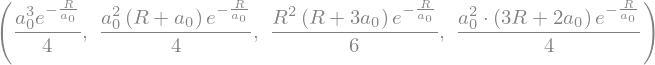

In [8]:
A0,r,R = symbols('a_{0} r R', positive=True)
I1 = integrate(r**2*exp(-(2*r+R)/A0),(r,0,oo))
I2 = (R+A0)*integrate(r*exp(-(2*r+R)/A0),(r,0,oo))
I3 = integrate((r*(R-r)+A0*r)*exp(-R/A0),(r,0,R))
I4 = integrate((r*(r-R)+A0*r)*exp(-(2*r-R)/A0),(r,R,oo))
from sympy import simplify
simplify(I1), simplify(I2), simplify(I3), simplify(I4)

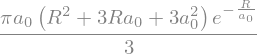

In [9]:
simplify(-((2*pi*A0)/R)*(I1+I2-I3-I4))

Tendo a integral de overlap, obtemos a constante de normalização e a função de onda teste
\begin{align}
& A = \frac{1}{\sqrt{2(1+I)}} = \frac{1}{\sqrt{2\big(1+\big(R^{2}/3a_{0}^{2} + R/a_{0}+1\big)e^{-R/a_{0}}\big)}}, \\
& \phi = \frac{\psi_{0}(r_{1})+\psi_{0}(r_{2})}{\sqrt{2\big(1+\big(R^{2}/3a_{0}^{2} + R/a_{0}+1\big)e^{-R/a_{0}}\big)}}.
\end{align}

Seguindo, vamos usar
$$\Big(-\frac{\hbar^{2}}{2m_{e}}\nabla^{2}-\frac{ke^{2}}{r}\Big)\psi_{0}(r)=E_{1}^{(0)}\psi_{0}(r).$$
Com isso, vem que
\begin{align}
H\phi & = \Big(-\frac{\hbar^{2}}{2m_{e}}\nabla^{2}-\frac{ke^{2}}{r}-\frac{ke^{2}}{r_{2}}\Big)A\big(\psi_{0}(r)+\psi_{0}(r_{2})\big) \\
& = A\Big(\Big(-\frac{\hbar^{2}}{2m_{e}}\nabla^{2}-\frac{ke^{2}}{r}\Big)\psi_{0}(r) + \Big(-\frac{\hbar^{2}}{2m_{e}}\nabla^{2}-\frac{ke^{2}}{r_{2}}\Big)\psi_{0}(r_{2}) - ke^{2}\Big(\frac{\psi_{0}(r)}{r_{2}}+\frac{\psi_{0}(r_{2})}{r}\Big)\Big) \\
& = A\Big(E_{1}^{(0)}\psi_{0}(r) + E_{1}^{(0)}\psi_{0}(r_{2}) - ke^{2}\Big(\frac{\psi_{0}(r)}{r_{2}}+\frac{\psi_{0}(r_{2})}{r}\Big)\Big) \\
& = E_{1}^{(0)}\phi - Ake^{2}\Big(\frac{\psi_{0}(r)}{r_{2}}+\frac{\psi_{0}(r_{2})}{r}\Big).
\end{align}

Assim
\begin{align}
\langle H\rangle_{\phi} & = \int d^{3}r \phi^{*}H\phi \\
& = E_{1}^{(0)}\int d^{3}r|\phi|^{2} - |A|^{2}ke^{2}\int d^{3}r \big(\psi_{0}(r)^{*}+\psi_{0}(r_{2})^{*}\big)\Big(\frac{\psi_{0}(r)}{r_{2}}+\frac{\psi_{0}(r_{2})}{r}\Big) \\
& = E_{1}^{(0)} - A^{2}ke^{2}\Big(\int d^{3}r \psi_{0}(r)\frac{1}{r_{2}}\psi_{0}(r) + \int d^{3}r \psi_{0}(r)\frac{1}{r}\psi_{0}(r_{2}) \\
& \hspace{3cm} + \int d^{3}r \psi_{0}(r_{2})\frac{1}{r_{2}}\psi_{0}(r) + \int d^{3}r \psi_{0}(r_{2})\frac{1}{r}\psi_{0}(r_{2}) \Big) \\
& = E_{1}^{(0)} - 2A^{2}ke^{2}\Big(\int d^{3}r \psi_{0}(r)\frac{1}{r_{2}}\psi_{0}(r) + \int d^{3}r \psi_{0}(r)\frac{1}{r}\psi_{0}(r_{2}) \Big) \\
& = E_{1}^{(0)} - 2A^{2}ke^{2}(I_{D} + I_{T}).
\end{align}
Passemos agora para o cálculo da chamada __integral direta__
\begin{align}
I_{D} & = \int d^{3}r \psi_{0}(r)\frac{1}{r_{2}}\psi_{0}(r) \\
& \equiv \langle\psi_{0}|\Big(\int d^{3}r \frac{|\vec{r}\rangle\langle \vec{r}|}{r_{2}}\Big)|\psi_{0}\rangle \\
& = \frac{1}{\pi a_{0}^{3}}\int_{0}^{2\pi}d\phi\int_{0}^{\infty}r^{2}e^{-2r/a_{0}}dr\int_{0}^{\pi}\frac{\sin\theta d\theta}{ \sqrt{r^{2}+R^{2}-2rR\cos\theta}} \\
& = \frac{1}{\pi a_{0}^{3}}2\pi\int_{0}^{\infty}r^{2}e^{-2r/a_{0}}dr\frac{1}{rR}\big(r+R-|r-R|\big) \\
& = \frac{2}{R a_{0}^{3}}\Big(\int_{0}^{R}re^{-2r/a_{0}}dr2r + \int_{R}^{\infty}re^{-2r/a_{0}}dr2R \Big) \\\
& = \frac{2}{R a_{0}^{3}}\frac{a_{0}^{3}\big(1 - \big(1+R/a_{0}\big)e^{-2R/a_{0}}\big)}{2} \\
& = \frac{1}{R} - \Big(\frac{1}{R} + \frac{1}{a_{0}}\Big)e^{-2R/a_{0}}.
\end{align}

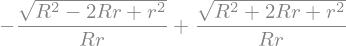

In [10]:
from sympy import sin, cos, sqrt
th = symbols('theta')
integrate(sin(th)/sqrt(r**2+R**2-2*r*R*cos(th)),(th,0,pi))

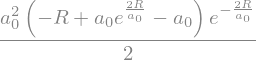

In [11]:
simplify(2*integrate(r**2*exp(-2*r/A0),(r,0,R)) + 2*R*integrate(r*exp(-2*r/A0),(r,R,oo)))

Já a chamada __integral de troca__ é obtida como segue
\begin{align}
I_{T} & = \int d^{3}r \psi_{0}(r)\frac{1}{r}\psi_{0}(r_{2})  \\
& \equiv \langle\psi_{0}|\Big(\int d^{3}r \frac{|\vec{r}\rangle\langle \vec{r}_{2}|}{r}\Big)|\psi_{0}\rangle \\
& = \frac{1}{\pi a_{0}^{3}}\int_{0}^{2\pi}d\phi\int_{0}^{\infty}\frac{r^{2}e^{-r/a_{0}}}{r}dr\int_{0}^{\pi} e^{-\sqrt{r^{2}+R^{2}-2rR\cos\theta}/a_{0}} \sin\theta d\theta \\
& = \frac{1}{\pi a_{0}^{3}}2\pi\int_{0}^{\infty}re^{-r/a_{0}}dr\int_{|r-R|/a_{a}}^{(r+R)/a_{0}} e^{-y} \frac{a_{0}^{2}ydy}{rR} \\
& = \frac{2}{R a_{0}}\int_{0}^{\infty}e^{-r/a_{0}}dr\Big(-\big(1+y\big)e^{-y}\Big)_{|r-R|/a_{0}}^{(r+R)/a_{0}} \\
& = \frac{2}{R a_{0}}\int_{0}^{\infty}e^{-r/a_{0}}dr\Big(-\big(1+(r+R)/a_{0}\big)e^{-(r+R)/a_{0}} + \big(1+|r-R|/a_{a}\big)e^{-|r-R|/a_{0}}\Big) \\
& = \frac{2}{R a_{0}}\Big(-\int_{0}^{\infty}e^{-r/a_{0}}dr\big(1+(r+R)/a_{0}\big)e^{-(r+R)/a_{0}} + \int_{0}^{R}e^{-r/a_{0}}dr\big(1+(R-r)/a_{a}\big)e^{-(R-r)/a_{0}} \\ 
& \hspace{2cm} + \int_{R}^{\infty}e^{-r/a_{0}}dr\big(1+(r-R)/a_{0}\big)e^{-(r-R)/a_{0}}\Big) \\
& = \frac{2}{R a_{0}}\Big(-\int_{0}^{\infty}dr\big(1+(r+R)/a_{0}\big)e^{-(2r+R)/a_{0}} + \int_{0}^{R}dr\big(1+(R-r)/a_{0}\big)e^{-R/a_{0}} \\ 
& \hspace{2cm} + \int_{R}^{\infty}dr\big(1+(r-R)/a_{0}\big)e^{-(2r-R)/a_{0}}\Big) \\
& = \frac{2}{R a_{0}}\frac{R(R+a_{0})e^{-R/a_{0}}}{2a_{0}} \\
& = \frac{1}{a_{0}}\Big(1+\frac{R}{a_{0}}\Big)e^{-R/a_{0}},
\end{align}
em que fizemos novamente a troca de variável 
$$y=\sqrt{r^{2}+R^{2}-2rR\cos\theta}/a_{0}\ \therefore\ d(y^{2}) = 2ydy=2rR\sin\theta d\theta/a_{0}^{2}.$$

In [12]:
y = symbols('y'); integrate(y*exp(-y))

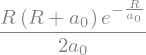

In [13]:
simplify(-integrate((1+(r+R)/A0)*exp(-(2*r+R)/A0),(r,0,oo)) + integrate((1+(R-r)/A0)*exp(-R/A0),(r,0,R)) 
        + integrate((1+(r-R)/A0)*exp(-(2*r-R)/A0),(r,R,oo)))

Temos assim que
\begin{align}
\langle H\rangle_{\phi} & = E_{1}^{(0)} - 2A^{2}ke^{2}(I_{D} + I_{T}) \\
& = E_{1}^{(0)} - 2\frac{1}{2\big(1+\big(R^{2}/3a_{0}^{2} + R/a_{0}+1\big)e^{-R/a_{0}}\big)}ke^{2}\Big(\frac{1}{R} - \Big( \frac{1}{R} + \frac{1}{a_{0}}\Big)e^{-2R/a_{0}} + \frac{1}{a_{0}}\Big(1+\frac{R}{a_{0}}\Big)e^{-R/a_{0}} \Big).
\end{align}

Para obter a __energia total__, $E$, incluímos também a energia coulombiana de interação próton-próton:
\begin{align}
U_{pp} & = \frac{ke^{2}}{R} = \frac{ke^{2}}{R}\frac{E_{1}^{(0)}}{E_{1}^{(0)}} = -\frac{ke^{2}}{R}\frac{2a_{0}}{ke^{2}}E_{1}^{(0)} = -\frac{2a_{0}}{R}E_{1}^{(0)},
\end{align}
em que usamos $E_{1}^{(0)} = -\frac{m_{e}k^{2}e^{4}}{2\hbar^{2}} = -\frac{ke^{2}}{2a_{0}}$. 

Por conseguinte
\begin{align}
\langle H_{t}\rangle_{\phi} & = \langle H\rangle_{\phi} + U_{pp} \\
& = E_{1}^{(0)} - \frac{1}{\big(1+\big(R^{2}/3a_{0}^{2} + R/a_{0}+1\big)e^{-R/a_{0}}\big)}ke^{2}\Big(\frac{1}{R} - \Big( \frac{1}{R} + \frac{1}{a_{0}}\Big)e^{-2R/a_{0}} + \frac{1}{a_{0}}\Big(1+\frac{R}{a_{0}}\Big)e^{-R/a_{0}} \Big) -\frac{2a_{0}}{R}E_{1}^{(0)} \\
& = E_{1}^{(0)}\Big(1-\frac{2a_{0}}{R}\Big) - \frac{1}{\big(1+\big(R^{2}/3a_{0}^{2} + R/a_{0}+1\big)e^{-R/a_{0}}\big)}\frac{ke^{2}}{R}\Big(1 - \Big(1 + \frac{R}{a_{0}}\Big)e^{-2R/a_{0}} + \frac{R}{a_{0}}\Big(1+\frac{R}{a_{0}}\Big)e^{-R/a_{0}} \Big) \\
& = E_{1}^{(0)}\Big(1-\frac{2a_{0}}{R}\Big) - \frac{1}{\big(1+\big(R^{2}/3a_{0}^{2} + R/a_{0}+1\big)e^{-R/a_{0}}\big)}\frac{-2a_{0}}{R}E_{1}^{(0)}\Big(1 - \Big(1 + \frac{R}{a_{0}}\Big)e^{-2R/a_{0}} + \frac{R}{a_{0}}\Big(1+\frac{R}{a_{0}}\Big)e^{-R/a_{0}} \Big) \\
& = -E_{1}^{(0)}\Big(-1+\frac{2}{x} - \frac{2}{x}\frac{1 - (1 + x)e^{-2x} + x(1+x)e^{-x}}{1+\big(x^{2}/3 + x+1\big)e^{-x}}\Big) \\
& = -E_{1}^{(0)}\Big(-1+\frac{2}{x}\Big( 1 - \frac{1 - (1 + x)e^{-2x} + x(1+x)e^{-x}}{1+\big(x^{2}/3 + x+1\big)e^{-x}}\Big)\Big) \\
& = -E_{1}^{(0)}\Big(-1+\frac{2}{x}\Big(\frac{1+\big(x^{2}/3 + x+1\big)e^{-x} -1 + (1 + x)e^{-2x} - x(1+x)e^{-x}}{1+\big(x^{2}/3 + x+1\big)e^{-x}}\Big)\Big) \\
& = -E_{1}^{(0)}\Big(-1+\frac{2}{x}\Big(\frac{(1-2x^{2}/3)e^{-x}+ (1 + x)e^{-2x}}{1+\big(x^{2}/3 + x+1\big)e^{-x}}\Big)\Big) \\
& = -E_{1}^{(0)}f(x),
\end{align}
em que definimos $$x:=\frac{R}{a_{0}}.$$

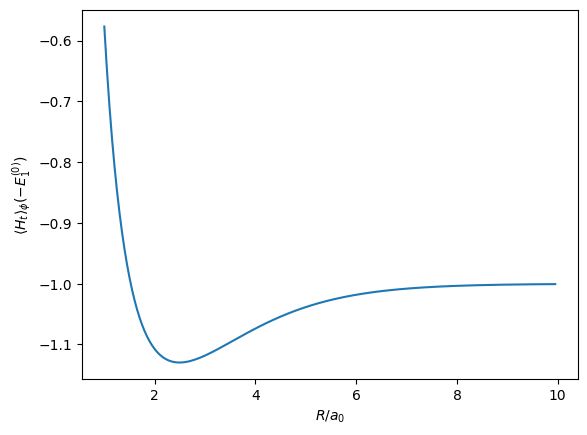

In [14]:
def Htm(x): # em unidade de -E_1^0
    return -1 + (2*x**-1)*(((1-2*x**2/3)*np.exp(-x)+(1+x)*np.exp(-2*x))/(1+(1+x+x**2/3)*np.exp(-x)))

from matplotlib import pyplot as plt
import matplotlib
import numpy as np
x = np.arange(1,10,0.05)
y = Htm(x); plt.plot(x,y)
#yb = -np.ones(len(x)); plt.plot(x,yb)
plt.ylabel(r'$\langle H_{t}\rangle_{\phi}(-E_{1}^{(0)})$')
plt.xlabel(r'$R/a_{0}$')
plt.show()

Vemos assim que existe um estado ligado para o íon da molécula de hidrogênio, pois a energia tem um mínimo menor que $-E_{1}^{(0)}$, que é a energia de um átomo de hidrogênio mais um próton livre. Funções de onda teste melhores nos fornecerão energias de ligação ainda menores. Note que aqui o parâmetro variacional é $R$, a distância entre os prótons. Na sequência obteremos o valor de $R$ que minimiza $\langle H_{t}\rangle_{\phi}$. 

Com a ajuda do código abaixo, vemos que
$$R_{opt} \approx 2.49a_{0} \approx 1.32\ \overset{\circ}{A}.$$
O valor experimental é
$$R_{exp} = 1.06\ \overset{\circ}{A}.$$
A __energia de ligação__, que é a diferença da energia da molécula de hidrogêncio ionizada, que estamos limitando superiormente por $\langle H_{t}\rangle$, e a energia de um átomo de hidrogênio mais um próton livre, que é $E_{1}^{0}$:
\begin{align}
E_{lig} & = E_{(p+e)+p} - E_{(2p+e)} \\
& \approx -13.6\text{ eV} + 15.37\text{ eV} \\
& \approx 1.76\text{ eV},
\end{align}
enquanto que o valor experimental é
$$E_{lig}^{exp} \approx 2.8\text{ eV}.$$

In [15]:
from sympy import diff
x = symbols('x')
Htm_ = -1 + (2*x**-1)*(((1-2*x**2/3)*exp(-x)+(1+x)*exp(-2*x))/(1+(1+x+x**2/3)*exp(-x)))
dHtm = diff(Htm_,x,1)
print(simplify(dHtm))

2*(x**2*(x + 1)*(3*x + (3 - 2*x**2)*exp(x) + 3) + x*(-6*x + (2*x**2 - 4*x - 3)*exp(x) - 3)*(x**2 + 3*x + 3*exp(x) + 3) + (-3*x + (2*x**2 - 3)*exp(x) - 3)*(x**2 + 3*x + 3*exp(x) + 3))*exp(-x)/(x**2*(x**2 + 3*x + 3*exp(x) + 3)**2)


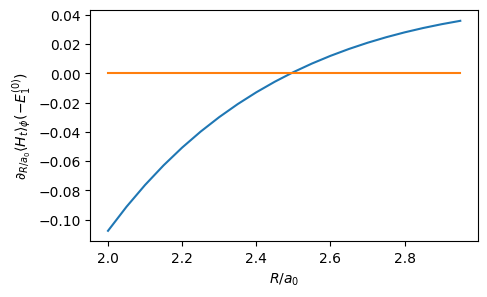

In [16]:
def dHtm(x):
    der = 2*(x**2*(x + 1)*(3*x + (3 - 2*x**2)*np.exp(x) + 3) 
            + x*(-6*x + (2*x**2 - 4*x - 3)*np.exp(x) - 3)*(x**2 + 3*x + 3*np.exp(x) + 3) 
            + (-3*x + (2*x**2 - 3)*np.exp(x) - 3)*(x**2 + 3*x + 3*np.exp(x) + 3))*np.exp(-x)/(x**2*(x**2 + 3*x + 3*np.exp(x) + 3)**2)
    return der

matplotlib.rcParams.update({'font.size':10})
plt.figure(figsize = (5,3), dpi = 100)
x = np.arange(2,3,0.05); y = dHtm(x); y1 = 0*x
plt.plot(x,y); plt.plot(x,y1)
plt.ylabel(r'$\partial_{R/a_{0}}\langle H_{t}\rangle_{\phi}(-E_{1}^{(0)})$')
plt.xlabel(r'$R/a_{0}$')
plt.show()

In [17]:
def bissection(f, xe, xd, err, Nm):
    # f: a função da qual queremos calcular as raízes
    # xe, xd ! limites "esquerdo" e "direito" para procurar a raíz
    # xm, fxm ! ponto médio e valor da função nesse ponto
    # xr ! valor da raíz
    # err ! largura máxima tolerada e atual do intervalo no qual procuramos a raíz
    # Nm, Ni ! número máximo e atual de iterações
    if f(xe)*f(xd) > 0:
        if abs(f(xe)) < 10**-15:
            xr = xe; er = 1; return xr, er
        if abs(f(xd)) < 10**-15:
            xr = xd; er = 1; return xr, er
        xr = 0; er = 0#; print('Não há raíz nesse intervalo')
    else:
        Ni = 0
        while True: 
            dx = xd-xe; xm = (xe+xd)/2#; print('xm = ',xm, ' f(xm) = ',f(xm))
            if dx < err:
                xr = xm; er = 1; return xr, er
            fxm = f(xm)
            if abs(fxm) < 10**-15:
                xr = xm; er = 1; return xr, er
            if f(xe)*f(xm) < 0:
                xd = xm
            else:
                xe = xm
            Ni = Ni + 1
            if Ni > Nm:
                er=0; break
        xr = xm; er = 1
    return xr, er

In [18]:
#%run numerics.ipynb
bissection(dHtm, 2, 3, 10**-5, 10**3) # valor otimo de x = R/a0

In [20]:
h = 6.626069*10**-34 # Js (constante de Planck)
import math
hb = h/(2*math.pi) # hbar
me = 9.109382*10**-31 # kg (massa do elétron)
k = 8.9875517923*10**9 # Nm^2/C^2 (constante de Coulomb)
e = 1.60217662*10**-19 # C (carga elementar)
a0=(hb**2)/(me*k*e**2) # ~ 0.52917710^-10 m (raio de Bohr)
2.49283218383789*a0  # valor otimo de R

In [21]:
def bohr(Z,n): # em eV
    return ((-((k*e**2)/(2*a0))/e)*Z**2)/n**2

# energia em unidades de -E1, em eV e energia de ligacao
Htm(2.49283218383789), Htm(2.49283218383789)*(-bohr(1,1)), bohr(1,1)-Htm(2.49283218383789)*(-bohr(1,1))

### Estabilidade da molécula

Em torno do ponto de mínima energia, $R_{opt}$, a curva de energia pode ser aproximada por aquela de um __oscilador harmônico__:
\begin{align} 
& U=\frac{m\omega^{2}x^{2}}{2}\ \therefore\ \partial_{xx}U = m\omega^{2} \\
& \omega = \sqrt{\partial_{xx}U/m}.
\end{align}
Dessa última equação vemos que podemos estimar a frequência de vibração do oscilador harmônico a partir do gráfico de energia.
Com a ajuda do código abaixo, obtemos
$$\big(\partial_{xx}f(x)\big)_{R_{opt}} \approx 0.13.$$
Notemos que como $x=R/a_{0}$, teremos
$$\partial_{xx}=\partial_{x}\partial_{x} = (\partial_{x}R)\partial_{R}(\partial_{x}R)\partial_{R} = a_{0}^{2}\partial_{RR}.$$
Então (lembra que $\langle H_{t}\rangle_{\phi} = \langle H\rangle_{\phi} + U_{pp} = -E_{1}^{(0)}f(x)$)
\begin{align}
\omega & = \sqrt{\frac{\partial_{RR}\langle H_{t}\rangle}{m}} \\
& = \sqrt{\frac{-(E_{1}^{(0)}/a_{0}^{2})\partial_{xx}f(x)}{m}} \\
& \approx 3.42\times 10^{14}\text{ Hz}.
\end{align}
com 
$$m=\frac{m_{p}m_{p}}{m_{p}+m_{p}} = \frac{m_{p}}{2}$$
sendo a massa reduzida dos 2 prótons.

In [22]:
def ddHtm(x):
    Htm_ = -1 + (2*x**-1)*(((1-2*x**2/3)*exp(-x)+(1+x)*exp(-2*x))/(1+(1+x+x**2/3)*exp(-x)))
    d2 = diff(Htm_,x,2)
    return d2
x = symbols('x')
print(simplify(ddHtm(x)))

2*(2*x**4*(x + 1)**2*(3*x + (3 - 2*x**2)*exp(x) + 3) + 12*x**3*(x**2 + 3*x + 3*exp(x) + 3)**2 - 2*x**2*(x + 1)*(3*x + (3 - 2*x**2)*exp(x) + 3)*(x**2 + 3*x + 3*exp(x) + 3) + x**2*(-2*x*(x + 1)*(6*x + (-2*x**2 + 4*x + 3)*exp(x) + 3) + (3*x + (3 - 2*x**2)*exp(x) + 3)*(-x**2 + x + 1))*(x**2 + 3*x + 3*exp(x) + 3) + x**2*(-2*x**2 + 8*x - 1)*(x**2 + 3*x + 3*exp(x) + 3)**2*exp(x) + 2*x*(6*x + (-2*x**2 + 4*x + 3)*exp(x) + 3)*(x**2 + 3*x + 3*exp(x) + 3)**2 + 2*(3*x + (3 - 2*x**2)*exp(x) + 3)*(x**2 + 3*x + 3*exp(x) + 3)**2)*exp(-x)/(x**3*(x**2 + 3*x + 3*exp(x) + 3)**3)


In [23]:
def d2Htm(x):
    d2 = 2*(2*x**4*(x + 1)**2*(3*x + (3 - 2*x**2)*exp(x) + 3) 
            + 12*x**3*(x**2 + 3*x + 3*exp(x) + 3)**2 
            - 2*x**2*(x + 1)*(3*x + (3 - 2*x**2)*exp(x) + 3)*(x**2 + 3*x + 3*exp(x) + 3) 
            + x**2*(-2*x*(x + 1)*(6*x + (-2*x**2 + 4*x + 3)*exp(x) + 3) 
                    + (3*x + (3 - 2*x**2)*exp(x) + 3)*(-x**2 + x + 1))*(x**2 + 3*x + 3*exp(x) + 3) 
            + x**2*(-2*x**2 + 8*x - 1)*(x**2 + 3*x + 3*exp(x) + 3)**2*exp(x) 
            + 2*x*(6*x + (-2*x**2 + 4*x + 3)*exp(x) + 3)*(x**2 + 3*x + 3*exp(x) + 3)**2 
            + 2*(3*x + (3 - 2*x**2)*exp(x) + 3)*(x**2 + 3*x + 3*exp(x) + 3)**2)*exp(-x)/(x**3*(x**2 + 3*x + 3*exp(x) + 3)**3)
    return d2
d2Htm(2.49283218383789)

In [24]:
# frequencia
mp = 1.6726219*10**-27 # kg (massa do próton)
om = sqrt((-((bohr(1,1)*e)/a0**2)*0.125665661374464)/(mp/2)) # passa a energia pra Joules
om

Para o estado fundamental do oscilador harmônico quântico teremos a energia
$$E_{0} = \frac{\hbar\omega}{2} = 0.11\text{ eV},$$
que é menor que a energia de ligação do $H_{2}^{+}$, que é $1.76\text{ eV}$. Portanto, pelo menos para este estado de oscilação nossos cálculos indicam que a $H_{2}^{+}$ não se quebrará.

Podemos obter também o número de estados do oscilador harmônico tais que $H_{2}^{+}$ não se quebra. Obtemos isso impondo
\begin{align}
\hbar\omega(n+1/2) \le 1.76\text{ eV}\ \therefore\ n\le \frac{1.76\text{ eV}}{\hbar\omega}-\frac{1}{2} \approx 7.32.
\end{align}
Temos então 8 estados ligados do oscilador para os quais a molécula é estável.

Vale notar que a energia térmica a temperatura ambiente ($300\text{ K}$) é aproximandamente $0.04\text{ eV}$, e portanto não é suficiente para excitar os modos de oscilação do oscilador a ponto de quebrar a molécula (cuja menor energia e $0.11\text{ eV}$).

In [25]:
((hb*342010081346730)/2)/e # energia de oscilacao em eV

In [26]:
# No. de estados ligados
nmax = (1.76)/(hb*om/e) -1/2; nmax

In [27]:
kB = 1.38065*10**-23 # J/K (constante de Boltzmann)
T = 300; (3*kB*T/2)/e # energia termica para temperatura ambiente

# Exercícios

$1.$ Considerando o íon da molécula de Hidrogênio, faça os cálculos para verificar que a função de onda teste 
$$\phi_{-} = A\big(\psi_{0}(r_{1})-\psi_{0}(r_{2})\big)$$
indica um estado não ligado para esta molécula.

$1.$ Qual seria a temperatura para a qual a energia térmica seria a mesma que a energia de oscilação necessária para quebrar a molécula $H_{2}^{+}$?